In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
import imageio
from tqdm import tqdm
import cartopy.crs as ccrs
import xesmf as xe
import dask
from utils import regrid_large_hres

In [2]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_1_ppt.grib')
hres

Ignoring index file '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_1_ppt.grib.5b7b6.idx' incompatible with GRIB file
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-16T12:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
print(hres)

<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-14T17:21 GRIB to CDM+CF via cfgrib-0.9.1...


In [14]:
unstructured_ds = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_8_ppt.grib', engine='cfgrib', chunks={'values': 'auto'})
unstructured_ds

Ignoring index file '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_8_ppt.grib.5b7b6.idx' incompatible with GRIB file
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB dask.array<chunksize=(6599680,), meta=np.ndarray>
    longitude   (values) float64 53MB dask.array<chunksize=(6599680,), meta=np.ndarray>
    valid_time  (step) datetime64[ns] 64B dask.array<chunksize=(8,), meta=np.ndarray>
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB dask.array<chunksize=(8, 4194304), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-16T12:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
# 2. Define your target grid (this is small and fits in memory)
target_lats = np.arange(-90, 91, 1.0) # 1x1 degree grid
target_lons = np.arange(0, 360, 1.0)
target_grid = xr.Dataset({
    'lat': (['lat'], target_lats),
    'lon': (['lon'], target_lons),
})
target_grid

<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 181, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    *empty*

In [16]:
print("\nBuilding the regridder with locstream_in=True...")
regridder = xe.Regridder(
    unstructured_ds, 
    target_grid, 
    'nearest_s2d',
    locstream_in=True  # CRITICAL FOR UNSTRUCTURED DATA
)
regridder


Building the regridder with locstream_in=True...


xESMF Regridder 
Regridding algorithm:       nearest_s2d 
Weight filename:            nearest_s2d_1x6599680_181x360.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1, 6599680) 
Output grid shape:          (181, 360) 
Periodic in longitude?      False

In [17]:
regridded_ds = regridder(unstructured_ds['tp'], keep_attrs=True)
regridded_ds

<xarray.DataArray 'tp' (step: 8, lat: 181, lon: 360)> Size: 2MB
dask.array<astype, shape=(8, 181, 360), dtype=float32, chunksize=(8, 181, 360), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 64B dask.array<chunksize=(8,), meta=np.ndarray>
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             6599680
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d

In [18]:
regridded_ds.load()

<xarray.DataArray 'tp' (step: 8, lat: 181, lon: 360)> Size: 2MB
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
...
        [2.2888184e-03, 2.2888184e-03, 2.1171570e-03, ...,
         2.4909973e-03, 2.4909973e-03, 2.2888184e-03],
        [2.6702881e-05, 2.6702881e-05, 2.6702881e-05, ...,
         3.8146973e-05, 2.6702881e-05, 2.6702881e-05],
        [1.1444092e-05, 1.1444092e-05, 1.1444092e-05, ...,
         1.1444092e-05, 1.1444092e-05, 1.1444092e-05]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         3.8146973e-06, 3.8146973e-06, 0.0000000e+00],
        ...,
        [2.8877258e-03, 2.8877258e-03, 2.6855469e-03, ...,
         3.1509399e-03, 3.1509399e-03, 2.8877258e-03],
        [2.6702881e-05, 2.6702881e-05, 2.6702881e-05, ...,
         4.5776367e-05, 2.6702881e-05, 2.6702881e-05],
        [1.1444092e-05, 1.1444092e-05, 1.1444092e-05, ...,
         1.1444092e-05, 1.1444092e-05, 1.1444092e-05]]], dtype=float32)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2022-07-08
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2022-07-08 ... 2022-07-08T07:00:00
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             6599680
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d

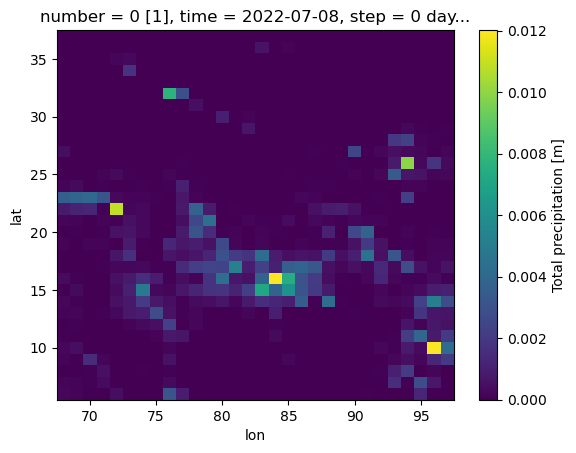

In [22]:
regridded_ds.isel(step=1).sel(lat=slice(6, 37), lon=slice(68, 97)).plot()

In [5]:
gridded_ds_stacked = hres.set_index(values=['latitude', 'longitude'])
gridded_ds_stacked

<xarray.Dataset> Size: 370MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 64B ...
  * values      (values) object 53MB MultiIndex
  * latitude    (values) float64 53MB 89.95 89.95 89.95 ... -89.95 -89.95 -89.95
  * longitude   (values) float64 53MB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-14T17:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:

# 2. Unstack the 'values' dimension into separate 'latitude' and 'longitude' dimensions.
#    This is the core operation that creates the regular grid.
gridded_ds = gridded_ds_stacked.unstack('values')
gridded_ds

<xarray.Dataset> Size: 164GB
Dimensions:     (latitude: 2560, longitude: 2005672, step: 8)
Coordinates:
  * latitude    (latitude) float64 20kB -89.95 -89.88 -89.81 ... 89.88 89.95
  * longitude   (longitude) float64 16MB 0.0 0.07009 0.07015 ... 359.9 359.9
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 64B ...
Data variables:
    tp          (step, latitude, longitude) float32 164GB 0.0 nan ... nan nan
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-14T17:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:

# 3. Rename dimensions and variables to match the target format.
#    The target uses 'lat', 'lon', and 'time' for dimensions.
#    It's also good practice to rename the data variable if needed, e.g., 'tp' to 'total_precipitation_6hr'.
gridded_ds_renamed = gridded_ds.rename({
    'latitude': 'lat',
    'longitude': 'lon',
    # 'step': 'time',
    'tp': 'total_precipitation_6hr' # Optional: rename variable to match target
})

In [8]:
gridded_ds_renamed = gridded_ds_renamed.rename({
    'time': 'date',
    'step': 'time'
})

In [9]:
gridded_ds_renamed.nbytes/ 1e9  # Size in MB

164.320716248

In [10]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe_updated1.nc").sel(time=slice('2015-07-01', '2015-07-31'))

In [16]:
gridded_one_step = gridded_ds_renamed.isel(time=1)

In [21]:
print(gridded_one_step)

<xarray.Dataset> Size: 21GB
Dimensions:                  (lat: 2560, lon: 2005672)
Coordinates:
  * lat                      (lat) float64 20kB -89.95 -89.88 ... 89.88 89.95
  * lon                      (lon) float64 16MB 0.0 0.07009 ... 359.9 359.9
    number                   int64 8B ...
    date                     datetime64[ns] 8B ...
    time                     timedelta64[ns] 8B 01:00:00
    surface                  float64 8B ...
    valid_time               datetime64[ns] 8B ...
Data variables:
    total_precipitation_6hr  (lat, lon) float32 21GB 0.0 nan nan ... nan nan nan
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-14T17:21 GRIB to CDM+CF via cfgrib-0.9.1...


In [22]:
gridded_one_step.nbytes / 1e9  # Size in GB

20.554147176

In [20]:
# Define target 1x1 degree grid
target_lats = np.arange(-90, 91, 1)
target_lons = np.arange(0, 360, 1)
target_grid = xr.Dataset({
    'lat': (['lat'], target_lats),
    'lon': (['lon'], target_lons),
})

# Create the regridder (bilinear is common for continuous fields)
regridder = xe.Regridder(gridded_one_step, target_grid, 'bilinear')

# Apply regridding
gridded_ds_1x1 = regridder(gridded_one_step)
gridded_ds_1x1

TypeError: buffer is too small for requested array

In [ ]:
regridder = xe.Regridder(gridded_ds_renamed.isel(time=1), imerg_test, "conservative")
regridder

KeyboardInterrupt: 

In [ ]:
# 4. Add the singleton 'batch' dimension to match the target.
gridded_ds_expanded = gridded_ds_renamed.expand_dims('batch')

# 5. Ensure coordinate order and sorting matches the target (optional but good practice).
#    The target has latitude descending (North to South).
gridded_ds_final = gridded_ds_expanded.isel(time=1).sortby('lat', ascending=False)
gridded_ds_final = gridded_ds_final.sortby('lon', ascending=True)

In [ ]:
gridded_ds_final.nbytes

NameError: name 'gridded_ds_final' is not defined

In [ ]:
gridded_ds_final.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_gridded_onestep.nc', mode='w')

In [ ]:
gridded_ds_final['total_precipitation_6hr'].plot()

In [2]:
for init_time in range(8,23,7):
    print(init_time)

8
15
22


In [5]:
for init_time in range(8,23,7):
    file_name = f'/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_{init_time}_ppt.grib'
    hres = xr.open_dataset(file_name)
    filenames = []
    steps_len = len(hres.step)
    for i in tqdm(range(steps_len)):
        da = hres.isel(step=i)['tp']
        fig = plt.figure(figsize=(12, 8))
        ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=80, central_latitude=22))
        scatter = ax.scatter(
            x=da['longitude'],
            y=da['latitude'],
            c=da,
            s=5,
            cmap='plasma',
            transform=ccrs.PlateCarree()
        )
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--')
        ax.set_extent([67, 97, 6, 38], crs=ccrs.PlateCarree())
        cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
        cbar.set_label(f"{da.long_name} ({da.units})")
        ax.set_title(f'Precipitation Map over India (step={i}) for 2022-07-{init_time}', fontsize=16)
        fname = f"hres_figures/hres_precip_step_{i}_2022-07-{init_time}.png"
        plt.savefig(fname)
        filenames.append(fname)
        plt.close(fig)

Ignoring index file '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_8_ppt.grib.5b7b6.idx' incompatible with GRIB file
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
100%|██████████| 8/8 [06:34<00:00, 49.31s/it]
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
100%|██████████| 8/8 [06:36<00:00, 49.60s/it]
/hom

In [3]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/hres_2022_07_22_ppt.grib')
hres

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-11T13:42 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
# Create a directory to save images
os.makedirs("hres_figures", exist_ok=True)
filenames = []
steps_len = len(hres.step)
for i in tqdm(range(steps_len)):
    da = hres.isel(step=i)['tp']
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=80, central_latitude=22))
    scatter = ax.scatter(
        x=da['longitude'],
        y=da['latitude'],
        c=da,
        s=5,
        cmap='plasma',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.gridlines(draw_labels=True, linestyle='--')
    ax.set_extent([67, 97, 6, 38], crs=ccrs.PlateCarree())
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
    cbar.set_label(f"{da.long_name} ({da.units})")
    ax.set_title(f'Precipitation Map over India (step={i}) for 2022-07-22', fontsize=16)
    fname = f"hres_figures/hres_precip_step_{i}_2022-07-22.png"
    plt.savefig(fname)
    filenames.append(fname)
    plt.close(fig)

# Create GIF
with imageio.get_writer('precipitation_over_time_hres_2022-07-22.gif', mode='I', duration=0.5) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print("GIF saved as precipitation_over_time.gif")

100%|██████████| 8/8 [06:28<00:00, 48.51s/it]
/tmp/ipykernel_3230861/785849671.py:31: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved as precipitation_over_time.gif


In [68]:
base_path = '/Datastorage/saptarishi.dhanuka_asp25/'
file_name = 'predictions_old_india20223_imerg.nc'
file_path = os.path.join(base_path, 'preds_dir', file_name)
imerg_finetuned = xr.open_dataset(file_path)

/tmp/ipykernel_3311106/269481543.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  imerg_finetuned = xr.open_dataset(file_path)


In [75]:
imerg_finetuned.isel(time=1)['total_precipitation_6hr'].sum()

<xarray.DataArray 'total_precipitation_6hr' ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    time     timedelta64[ns] 8B 12:00:00

In [32]:
print(len(imerg_finetuned.time.values))

28


In [56]:
imerg_finetuned.isel(time=2)['2m_temperature'].squeeze() 

<xarray.DataArray '2m_temperature' (lat: 181, lon: 360)> Size: 261kB
[65160 values with dtype=float32]
Coordinates:
    time     timedelta64[ns] 8B 18:00:00
  * lat      (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float32 1kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0

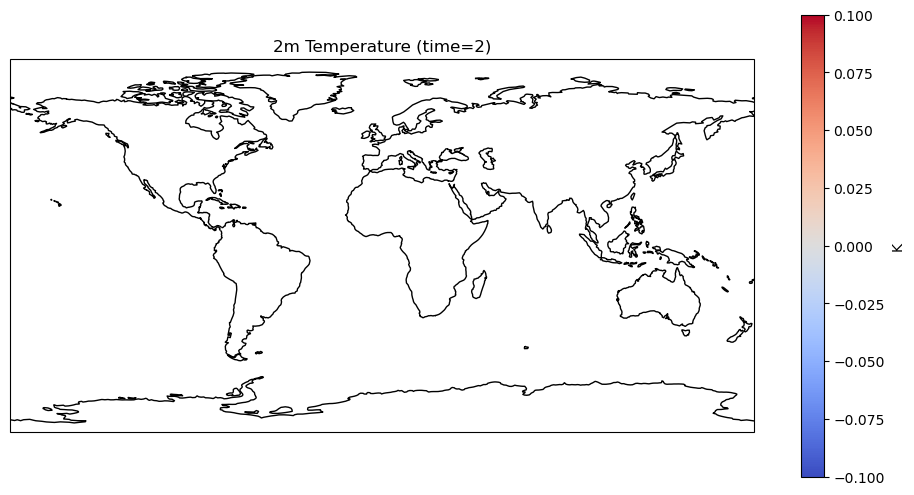

In [67]:
da = imerg_finetuned.isel(time=2)['2m_temperature']  # remove batch dim if needed

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
mesh = ax.pcolormesh(da['lon'], da['lat'], da[0, :, :], cmap='coolwarm', transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_title('2m Temperature (time=2)')
plt.colorbar(mesh, ax=ax, orientation='vertical', label='K')
plt.show()